In [20]:
!pip install transformers torch -q

import pandas as pd
import numpy as np
import torch
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [21]:
import random
import numpy as np
import torch

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [22]:
import pandas as pd
df = pd.read_csv("cleaned_medical_data.csv")
df.head()

,disease,pubmed_id,abstract,symptoms,age,gender,drugs
0,covid-19,42083698,dengue hemorrhagic fever dhf is a severe form ...,"['abdominal pain', 'fever', 'headache', 'nausea']",17,female,"['remdesivir', 'molnupiravir', 'nirmatrelvir',..."
1,covid-19,42078607,chronic inflammatory demyelinating polyneuropa...,"['arthralgia', 'cough', 'fatigue', 'fever', 'f...",20,female,"['remdesivir', 'molnupiravir', 'nirmatrelvir',..."
2,covid-19,42078597,coronavirus disease 2019 covid-19 vaccines hav...,"['autoimmune hepatitis aih', 'progression to l...",64,male,"['remdesivir', 'molnupiravir', 'nirmatrelvir',..."
3,covid-19,42078216,"paxlovid, a codrug of nirmatrelvirritonavir, h...","['bradycardia', 'hypotension']",81,female,"['remdesivir', 'molnupiravir', 'nirmatrelvir',..."
4,covid-19,42076904,alport syndrome as is a hereditary nephropathy...,"['fever', 'fatigue', 'cough', 'headache', 'wea...",48,unknown,"['remdesivir', 'molnupiravir', 'nirmatrelvir',..."


In [23]:
import ast
# Feature Engineering & Encoding for gender 
df['symptoms'] = df['symptoms'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df['text_input'] = df['abstract'] + " " + df['symptoms'].apply(lambda x: ' '.join(x))
df['gender_enc'] = df['gender'].map({'female': 0, 'male': 1, 'unknown': 2})


In [24]:
df.head()

,disease,pubmed_id,abstract,symptoms,age,gender,drugs,text_input,gender_enc
0,covid-19,42083698,dengue hemorrhagic fever dhf is a severe form ...,"[abdominal pain, fever, headache, nausea]",17,female,"['remdesivir', 'molnupiravir', 'nirmatrelvir',...",dengue hemorrhagic fever dhf is a severe form ...,0
1,covid-19,42078607,chronic inflammatory demyelinating polyneuropa...,"[arthralgia, cough, fatigue, fever, frequent f...",20,female,"['remdesivir', 'molnupiravir', 'nirmatrelvir',...",chronic inflammatory demyelinating polyneuropa...,0
2,covid-19,42078597,coronavirus disease 2019 covid-19 vaccines hav...,"[autoimmune hepatitis aih, progression to live...",64,male,"['remdesivir', 'molnupiravir', 'nirmatrelvir',...",coronavirus disease 2019 covid-19 vaccines hav...,1
3,covid-19,42078216,"paxlovid, a codrug of nirmatrelvirritonavir, h...","[bradycardia, hypotension]",81,female,"['remdesivir', 'molnupiravir', 'nirmatrelvir',...","paxlovid, a codrug of nirmatrelvirritonavir, h...",0
4,covid-19,42076904,alport syndrome as is a hereditary nephropathy...,"[fever, fatigue, cough, headache, weakness]",48,unknown,"['remdesivir', 'molnupiravir', 'nirmatrelvir',...",alport syndrome as is a hereditary nephropathy...,2


In [25]:
# encode for target
le = LabelEncoder()
df['label'] = le.fit_transform(df['disease'])
print(le.classes_)
print(df['label'].value_counts())

['covid-19' 'lung cancer' 'pneumonia' 'tuberculosis']
label
1    156
0    153
3    151
2    142
Name: count, dtype: int64


In [26]:
#  split
X_text = df['text_input'].values
X_struct = df[['age', 'gender_enc']].values.astype(float)
y = df['label'].values

X_text_train, X_text_test, X_struct_train, X_struct_test, y_train, y_test = train_test_split(
    X_text,
    X_struct,
    y,
    test_size=0.2,
    stratify=y, 
    random_state=42
)

print("Train:", len(X_text_train))
print("Test:", len(X_text_test))

Train: 481
Test: 121


In [27]:
# tokenization

tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def tokenize(texts, max_len=256):
    return tokenizer(
        list(texts),
        max_length=max_len,
        padding=True,
        truncation=True,
        return_tensors='pt' 
    )

train_encodings = tokenize(X_text_train)
test_encodings  = tokenize(X_text_test)

print("Train tokens shape:", train_encodings['input_ids'].shape)
print("Test tokens shape:", test_encodings['input_ids'].shape)


Train tokens shape: torch.Size([481, 256])
Test tokens shape: torch.Size([121, 256])


In [28]:
# Dataloader
class MedicalDataset(Dataset):
    def __init__(self, encodings, struct_features, labels):
        self.encodings = encodings
        self.struct_features = torch.tensor(struct_features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'struct': self.struct_features[idx],
            'label': self.labels[idx]
        }

train_dataset = MedicalDataset(train_encodings, X_struct_train, y_train)
test_dataset  = MedicalDataset(test_encodings,  X_struct_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 31
Test batches: 8


In [29]:
from transformers import DistilBertModel

class DistilBertClassifier(nn.Module):

    def __init__(self):
        super().__init__()

        self.bert = DistilBertModel.from_pretrained(
            'distilbert-base-uncased'
        )

        # Freeze كل Layers
        for param in self.bert.parameters():
            param.requires_grad = False

        # فتح آخر Layerين
        for param in self.bert.transformer.layer[-2:].parameters():
            param.requires_grad = True

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear(768 + 2, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 4)
        )

    def forward(self, input_ids, attention_mask, struct):

        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_token = output.last_hidden_state[:, 0, :]

        combined = torch.cat([cls_token, struct], dim=1)

        return self.classifier(combined)

model = DistilBertClassifier()

print(model)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBertClassifier(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): L

In [30]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("works on ", device)

model = model.to(device)

# Optimizer
optimizer = torch.optim.Adam([

    # فتح آخر Layerين من DistilBERT
    {
        'params': model.bert.transformer.layer[-2:].parameters(),
        'lr': 2e-5
    },

    # classifier
    {
        'params': model.classifier.parameters(),
        'lr': 2e-4
    }

])

# Training Function
def train_epoch(model, loader):

    model.train()

    total_loss = 0
    correct = 0

    for batch in loader:

        input_ids = batch['input_ids'].to(device)

        attention_mask = batch['attention_mask'].to(device)

        struct = batch['struct'].to(device)

        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids,
            attention_mask,
            struct
        )

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        correct += (
            outputs.argmax(1) == labels
        ).sum().item()

    return (
        total_loss / len(loader),
        correct / len(loader.dataset)
    )

works on  cpu


In [31]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("works on ", device)

model = model.to(device)

optimizer = torch.optim.Adam([
    {'params': model.bert.transformer.layer[-1].parameters(), 'lr': 2e-5},
    {'params': model.classifier.parameters(), 'lr': 2e-4}
])

criterion = nn.CrossEntropyLoss()


def train_epoch(model, loader):
    model.train()
    total_loss, correct = 0, 0

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        struct         = batch['struct'].to(device)
        labels         = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask, struct)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


def eval_epoch(model, loader):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            struct         = batch['struct'].to(device)
            labels         = batch['label'].to(device)

            outputs = model(input_ids, attention_mask, struct)

            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


epochs = 12
best_loss = float('inf')
patience = 3
counter = 0

for epoch in range(epochs):

    train_loss, train_acc = train_epoch(model, train_loader)

    test_loss, test_acc = eval_epoch(model, test_loader)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.3f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Test Loss: {test_loss:.3f} | "
        f"Test Acc: {test_acc:.3f}"
    )

    if test_loss < best_loss:

        best_loss = test_loss
        counter = 0

        torch.save(model.state_dict(), 'best_model.pt')

        print("Best model saved!")

    else:
        counter += 1

        print(f"No improvement {counter}/{patience}")

        if counter >= patience:
            print("Early stopping!")
            break


model.load_state_dict(torch.load('best_model.pt'))

print("Best model loaded!")

works on  cpu
Epoch 1/12 | Train Loss: 1.402 | Train Acc: 0.274 | Test Loss: 1.339 | Test Acc: 0.322
Best model saved!
Epoch 2/12 | Train Loss: 1.328 | Train Acc: 0.349 | Test Loss: 1.235 | Test Acc: 0.479
Best model saved!
Epoch 3/12 | Train Loss: 1.198 | Train Acc: 0.482 | Test Loss: 0.936 | Test Acc: 0.645
Best model saved!
Epoch 4/12 | Train Loss: 0.892 | Train Acc: 0.649 | Test Loss: 0.762 | Test Acc: 0.727
Best model saved!
Epoch 5/12 | Train Loss: 0.712 | Train Acc: 0.740 | Test Loss: 0.700 | Test Acc: 0.777
Best model saved!
Epoch 6/12 | Train Loss: 0.663 | Train Acc: 0.786 | Test Loss: 0.664 | Test Acc: 0.785
Best model saved!
Epoch 7/12 | Train Loss: 0.520 | Train Acc: 0.832 | Test Loss: 0.613 | Test Acc: 0.785
Best model saved!
Epoch 8/12 | Train Loss: 0.454 | Train Acc: 0.854 | Test Loss: 0.636 | Test Acc: 0.793
No improvement 1/3
Epoch 9/12 | Train Loss: 0.387 | Train Acc: 0.871 | Test Loss: 0.642 | Test Acc: 0.802
No improvement 2/3
Epoch 10/12 | Train Loss: 0.396 | Train

In [32]:
torch.save(model.state_dict(), 'distilbert_model.pt')
print("Model saved!")



Model saved!


              precision    recall  f1-score   support

    covid-19       0.76      0.84      0.80        31
 lung cancer       0.79      0.84      0.81        31
   pneumonia       0.76      0.55      0.64        29
tuberculosis       0.82      0.90      0.86        30

    accuracy                           0.79       121
   macro avg       0.78      0.78      0.78       121
weighted avg       0.78      0.79      0.78       121



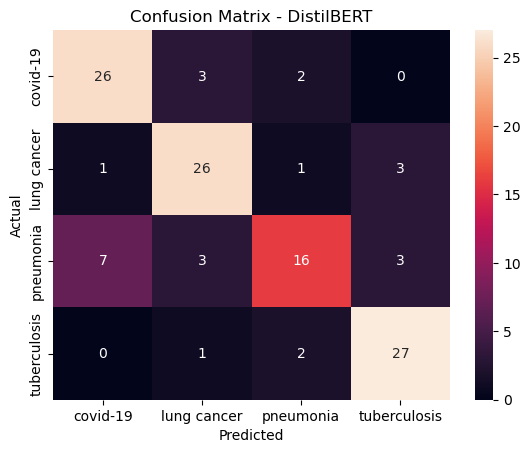

In [33]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        struct         = batch['struct'].to(device)
        labels         = batch['label'].to(device)

        outputs = model(input_ids, attention_mask, struct)
        preds   = outputs.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification Report
print(classification_report(all_labels, all_preds, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - DistilBERT')
plt.show()

In [34]:
#  for late fusion probabilities على الـ test set
import torch.nn.functional as F

model.eval()
distilbert_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        struct         = batch['struct'].to(device)

        outputs = model(input_ids, attention_mask, struct)
        probs   = F.softmax(outputs, dim=1)
        distilbert_probs.extend(probs.cpu().numpy())

distilbert_probs = np.array(distilbert_probs)
np.save('distilbert_probs.npy', distilbert_probs)
print("Probabilities saved!", distilbert_probs.shape)

Probabilities saved! (121, 4)


In [35]:
torch.save(model.state_dict(), 'distilbert_v2.pt')

print("Version 2 saved!")

Version 2 saved!
